In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/regressionproblem/sample_submission.csv
/kaggle/input/regressionproblem/test.csv
/kaggle/input/regressionproblem/data.csv


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
pd.options.display.max_columns=None

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
df = pd.read_csv('/kaggle/input/regressionproblem/data.csv')
df.head()

,id,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,y
0,9214,-1.269584,-0.471276,1.271286,1.181464,-0.100392,1.449701,1.377916,-0.065368,-0.292402,-0.227562,-6.744388
1,9936,-3.345712,0.962012,-0.010381,-1.143822,2.144663,0.002984,-0.062975,0.239043,1.026711,0.937543,-209.017251
2,6148,-0.177312,-0.654352,1.139073,0.449924,-0.428796,0.956123,1.523470,-0.016801,0.279851,-0.183580,136.280877
3,3466,-0.465802,1.430401,0.565258,-0.882161,0.228255,-0.579749,1.538078,2.194240,-0.029758,0.686409,92.047959
4,6878,1.145984,0.663759,1.589677,0.773086,0.838778,1.354121,-0.156710,-0.403062,0.140580,-1.136642,91.349775


In [4]:
df.infer_objects()

,id,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,y
0,9214,-1.269584,-0.471276,1.271286,1.181464,-0.100392,1.449701,1.377916,-0.065368,-0.292402,-0.227562,-6.744388
1,9936,-3.345712,0.962012,-0.010381,-1.143822,2.144663,0.002984,-0.062975,0.239043,1.026711,0.937543,-209.017251
2,6148,-0.177312,-0.654352,1.139073,0.449924,-0.428796,0.956123,1.523470,-0.016801,0.279851,-0.183580,136.280877
3,3466,-0.465802,1.430401,0.565258,-0.882161,0.228255,-0.579749,1.538078,2.194240,-0.029758,0.686409,92.047959
4,6878,1.145984,0.663759,1.589677,0.773086,0.838778,1.354121,-0.156710,-0.403062,0.140580,-1.136642,91.349775
...,...,...,...,...,...,...,...,...,...,...,...,...
11995,9941,1.209148,0.968248,-0.233942,-0.661826,0.068980,1.038689,1.342263,-0.475022,0.024588,-0.071629,216.940422
11996,3835,-0.202524,-0.876634,-0.379980,1.378035,-0.602254,-1.158553,1.115208,0.291473,1.088164,-1.236181,156.244277
11997,6101,0.577834,1.112086,-0.697342,0.123455,0.444490,-0.668361,-1.891849,0.695727,0.929277,-0.183775,-49.257565
11998,5435,-0.315841,-0.391228,-0.213742,-0.171128,1.823233,1.261355,1.930175,0.929642,-0.181617,2.091590,127.117060


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   id      12000 non-null  int64  
 1   x0      12000 non-null  float64
 2   x1      12000 non-null  float64
 3   x2      12000 non-null  float64
 4   x3      12000 non-null  float64
 5   x4      12000 non-null  float64
 6   x5      12000 non-null  float64
 7   x6      12000 non-null  float64
 8   x7      12000 non-null  float64
 9   x8      12000 non-null  float64
 10  x9      12000 non-null  float64
 11  y       12000 non-null  float64
dtypes: float64(11), int64(1)
memory usage: 1.1 MB


In [6]:
df.dtypes

id      int64
x0    float64
x1    float64
x2    float64
x3    float64
x4    float64
x5    float64
x6    float64
x7    float64
x8    float64
x9    float64
y     float64
dtype: object

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,12000.0,7494.513917,4324.286702,0.000000,3755.750000,7498.500000,11219.250000,14999.000000
x0,12000.0,0.004974,1.005618,-3.820123,-0.664412,0.002035,0.683925,3.877674
x1,12000.0,0.012140,0.999312,-4.029950,-0.655589,0.014120,0.690300,3.922182
x2,12000.0,-0.022285,0.993402,-3.929342,-0.679831,-0.039326,0.645138,3.744429
x3,12000.0,-0.012062,0.999454,-3.936197,-0.682227,-0.012313,0.665014,3.644103
x4,12000.0,0.003552,0.987673,-4.358125,-0.652337,-0.002225,0.658617,4.219952
x5,12000.0,-0.009410,1.000908,-4.136878,-0.685387,0.003303,0.660079,3.749046
x6,12000.0,0.004016,0.999135,-3.790943,-0.667220,0.005063,0.673609,3.627607
x7,12000.0,0.010196,1.012335,-3.629488,-0.677371,0.012616,0.696309,3.478818
x8,12000.0,-0.019022,0.999567,-3.869151,-0.692518,-0.013836,0.653956,3.339246


In [8]:
df.isnull().sum()/len('df')*100

id    0.0
x0    0.0
x1    0.0
x2    0.0
x3    0.0
x4    0.0
x5    0.0
x6    0.0
x7    0.0
x8    0.0
x9    0.0
y     0.0
dtype: float64

In [9]:
df.shape

(12000, 12)

<AxesSubplot: >

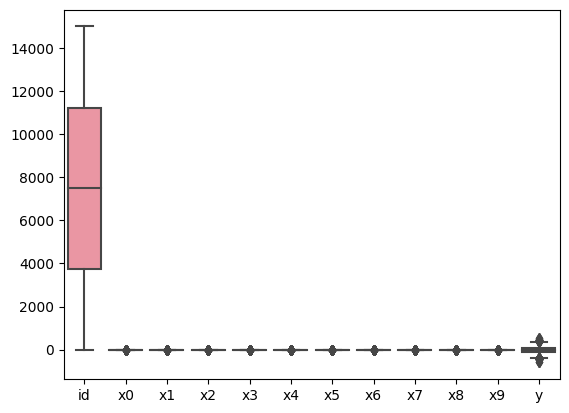

In [10]:
sns.boxplot(df)

<AxesSubplot: >

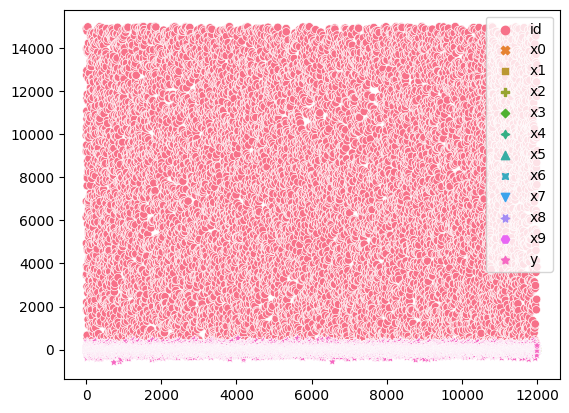

In [11]:
sns.scatterplot(df)

<AxesSubplot: ylabel='Density'>

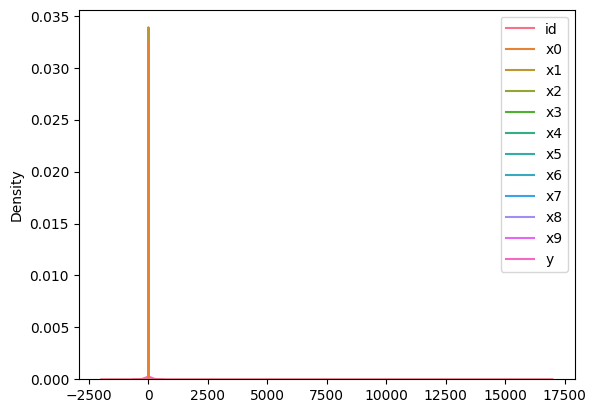

In [12]:
sns.kdeplot(df)

In [13]:
df.skew()

id    0.001268
x0    0.023969
x1   -0.025020
x2    0.025992
x3    0.013898
x4    0.002276
x5   -0.002328
x6    0.015671
x7   -0.017525
x8   -0.026008
x9   -0.033380
y     0.025513
dtype: float64

In [14]:
df.kurt()

id   -1.196887
x0    0.013014
x1    0.000106
x2   -0.004019
x3    0.007728
x4    0.153474
x5    0.037033
x6   -0.029503
x7   -0.083204
x8    0.000948
x9   -0.055300
y     0.030422
dtype: float64

<AxesSubplot: >

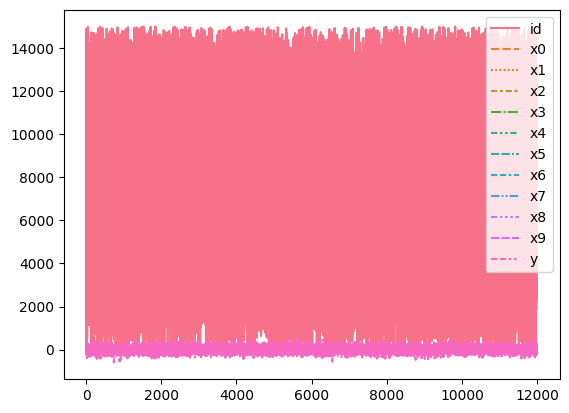

In [15]:
sns.lineplot(df)

<AxesSubplot: >

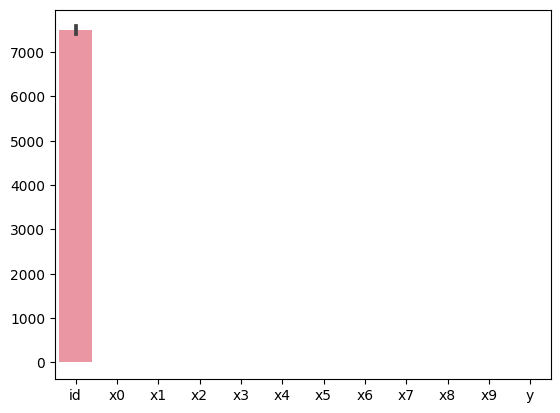

In [16]:
sns.barplot(df)

<AxesSubplot: >

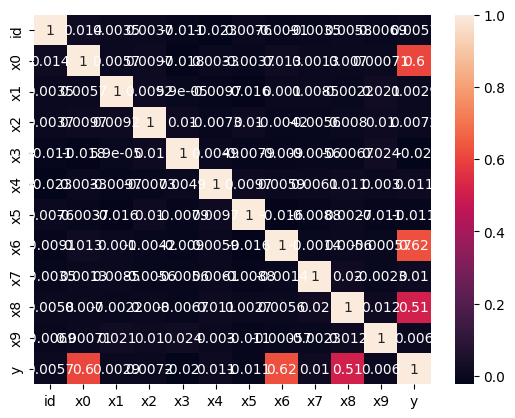

In [17]:
sns.heatmap(df.corr(),annot=True)

<AxesSubplot: >

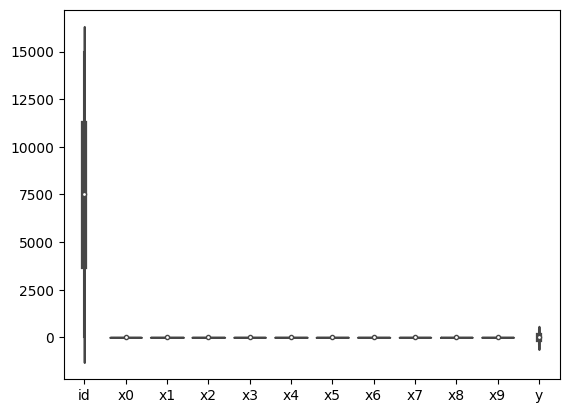

In [18]:
sns.violinplot(df)

In [19]:
cat_cols = df.select_dtypes(include='object')

In [20]:
for i in cat_cols:
    print(i)
    print(df[i].value_counts())
    print('_'*50)

In [21]:
num_cols = df.select_dtypes(include='number')

In [22]:
for i in num_cols:
    print(i)
    print(df[i].value_counts())
    print('_'*50)

id
9214     1
14376    1
6790     1
10180    1
11626    1
        ..
13525    1
11185    1
3493     1
4133     1
9237     1
Name: id, Length: 12000, dtype: int64
__________________________________________________
x0
-1.269584    1
-0.307230    1
-0.370984    1
 0.350871    1
-0.494098    1
            ..
 1.636663    1
-0.718917    1
-1.023077    1
 0.084817    1
 0.128226    1
Name: x0, Length: 12000, dtype: int64
__________________________________________________
x1
-0.471276    1
-0.602750    1
-1.868539    1
 0.379554    1
 0.162212    1
            ..
 0.789932    1
 1.251420    1
-0.134316    1
-0.713085    1
 1.255815    1
Name: x1, Length: 12000, dtype: int64
__________________________________________________
x2
 1.271286    1
-1.282141    1
 0.162439    1
-0.025514    1
-0.633243    1
            ..
-1.029146    1
-0.368451    1
-1.270797    1
-0.240612    1
-1.398156    1
Name: x2, Length: 12000, dtype: int64
__________________________________________________
x3
 1.181464    

In [23]:
df['id']=df['id'].map({'Good':1,'Standard':2,'Poor':0})

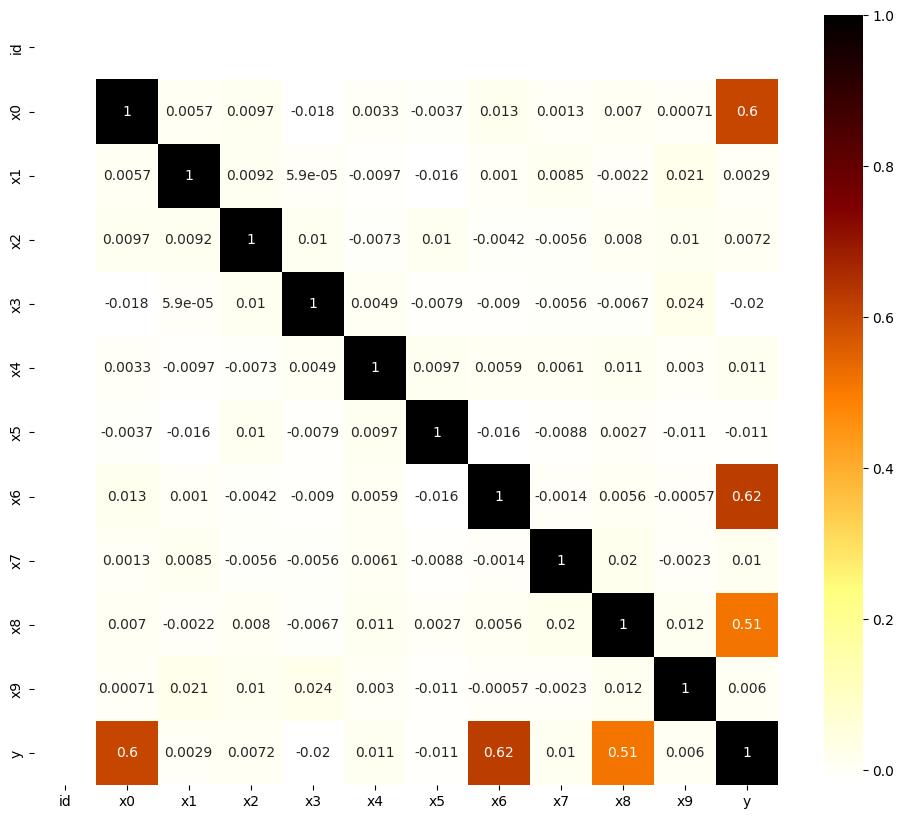

In [24]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(),annot=True,cmap='afmhot_r')
plt.show()

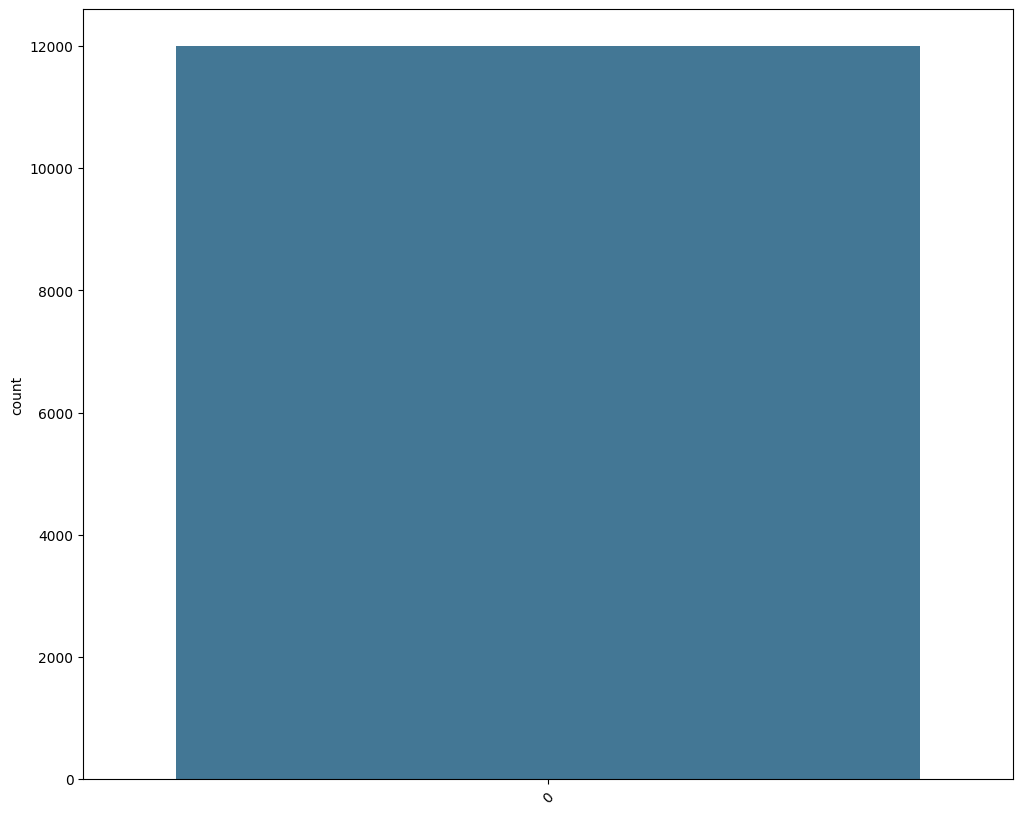

In [25]:
plt.figure(figsize=(12,10))
sns.countplot(df['id'],palette='mako');
plt.xticks(rotation=45);

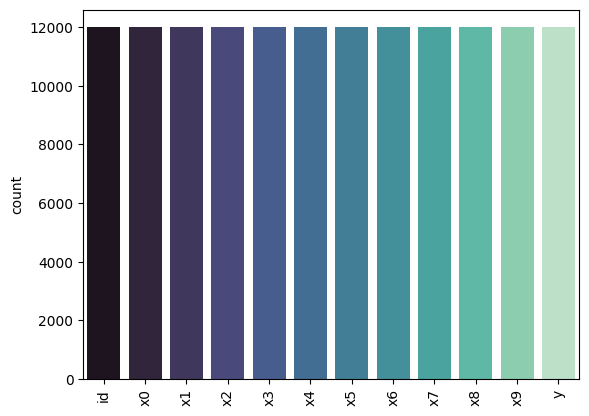

In [26]:
sns.countplot(df,palette='mako');
plt.xticks(rotation=90);

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]),
 [Text(0, 0, 'id'),
  Text(1, 0, 'x0'),
  Text(2, 0, 'x1'),
  Text(3, 0, 'x2'),
  Text(4, 0, 'x3'),
  Text(5, 0, 'x4'),
  Text(6, 0, 'x5'),
  Text(7, 0, 'x6'),
  Text(8, 0, 'x7'),
  Text(9, 0, 'x8'),
  Text(10, 0, 'x9'),
  Text(11, 0, 'y')])

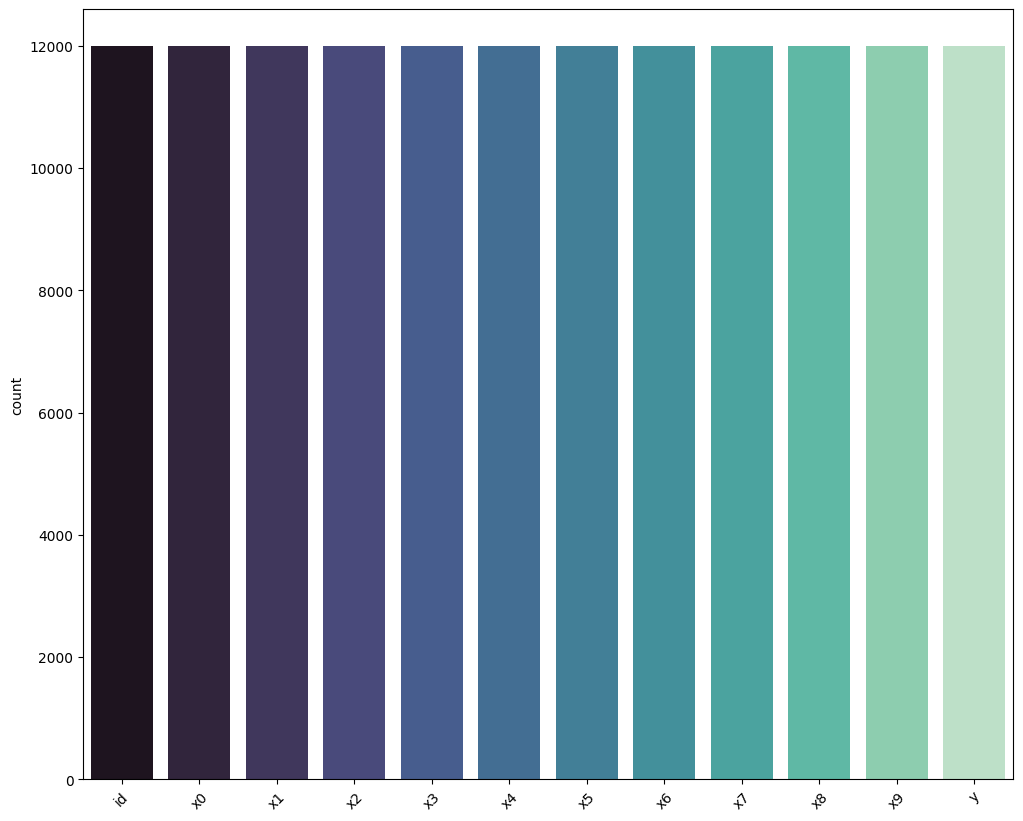

In [27]:
plt.figure(figsize=(12,10))
sns.countplot(df,palette='mako')
plt.xticks(rotation=45)

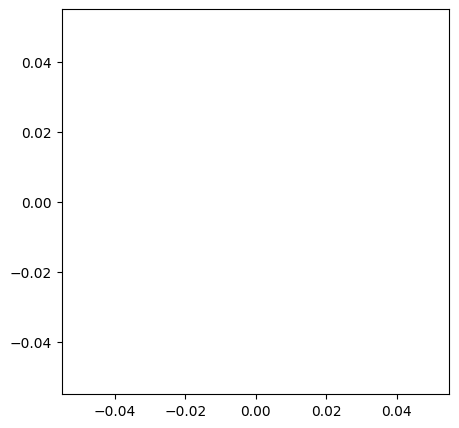

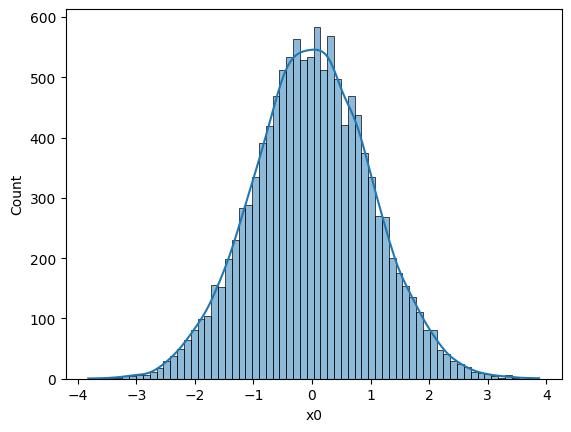

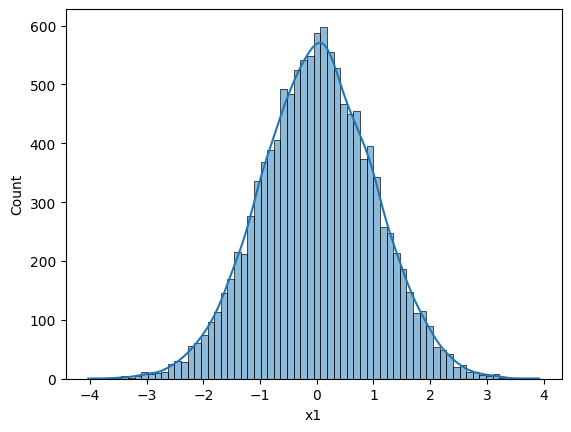

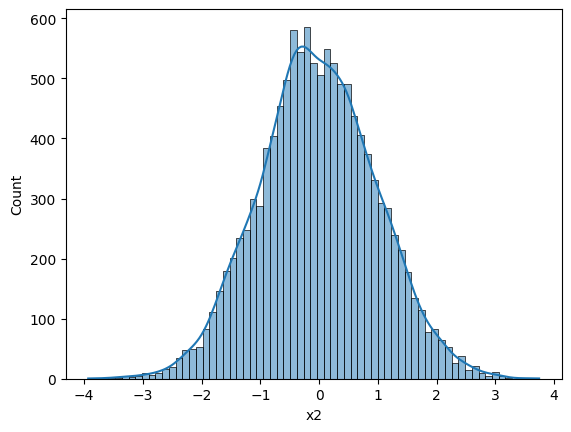

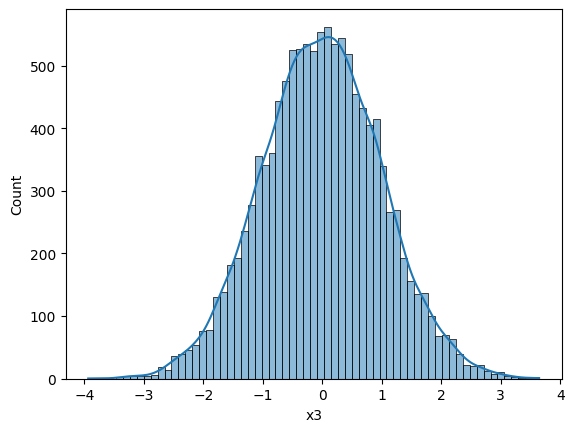

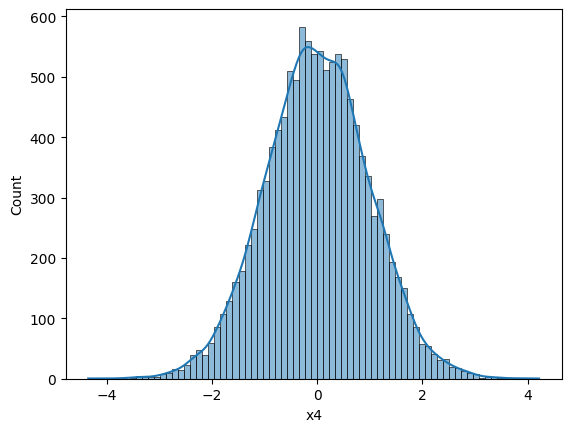

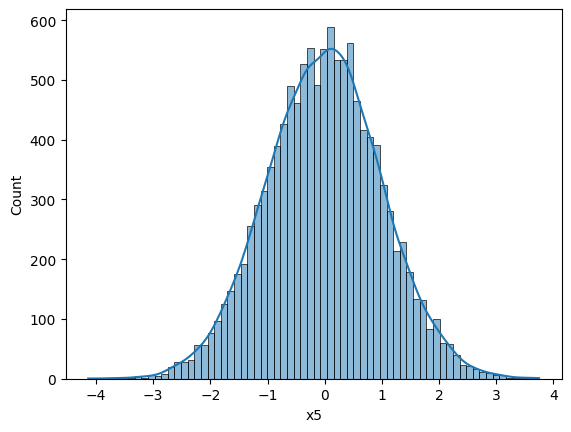

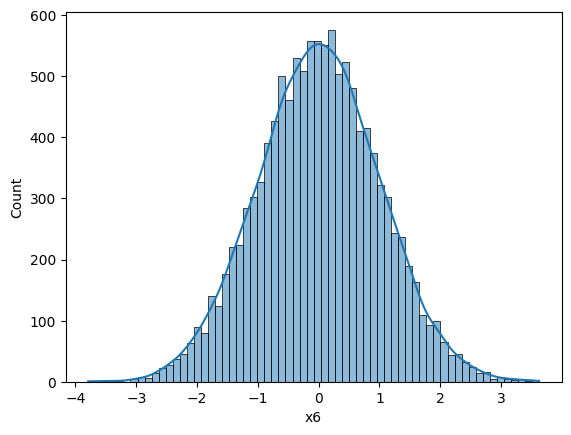

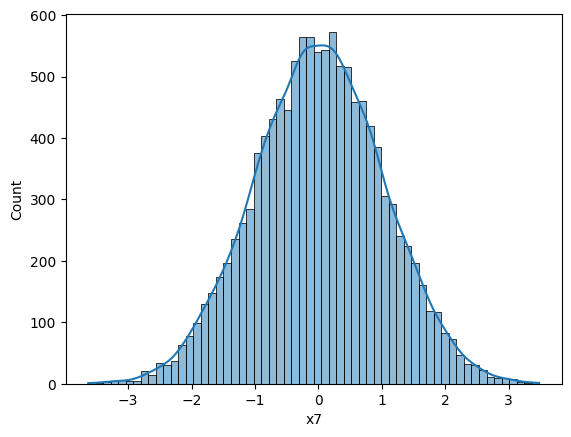

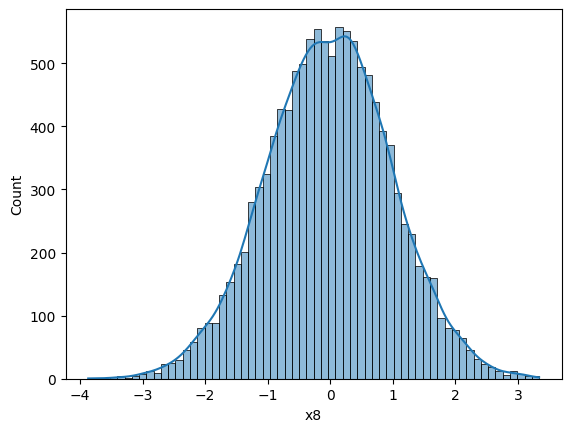

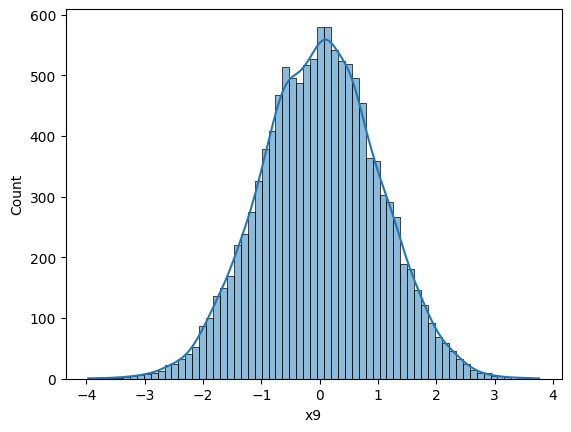

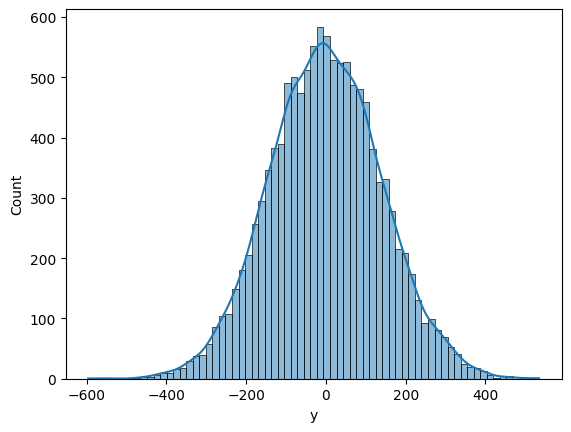

In [28]:
plt.figure(figsize=(5,5))
x=1
for i in num_cols:
    sns.histplot(data=df,x=i,kde=True)
    print('\n')
    plt.show()

In [29]:
x=1
for i in cat_cols:
    sns.countplot(data=df,x=i)
    print('\n')
    plt.show()

In [30]:
df['id'].value_counts()

Series([], Name: id, dtype: int64)

In [31]:
df['id'].unique()

array([nan])

<AxesSubplot: ylabel='count'>

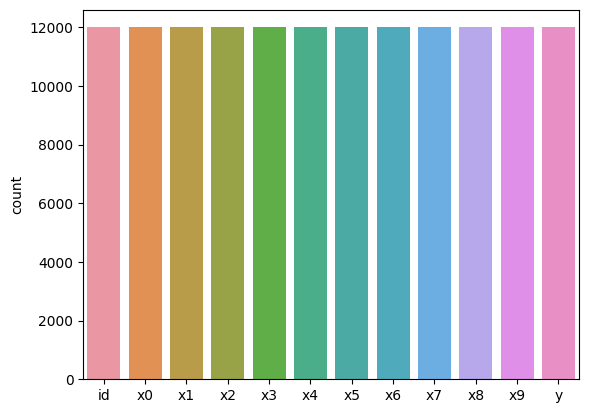

In [32]:
sns.countplot(df)

<AxesSubplot: xlabel='x0', ylabel='Count'>

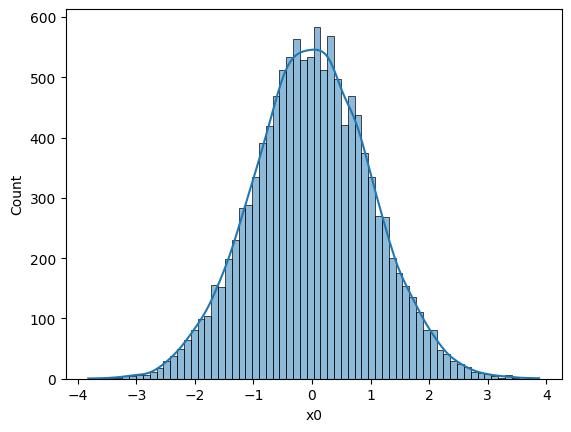

In [33]:
sns.histplot(df['x0'],kde=True)

In [34]:
df.head()

,id,x0,x1,x2,x3,x4,x5,x6,x7,x8,x9,y
0,NaN,-1.269584,-0.471276,1.271286,1.181464,-0.100392,1.449701,1.377916,-0.065368,-0.292402,-0.227562,-6.744388
1,NaN,-3.345712,0.962012,-0.010381,-1.143822,2.144663,0.002984,-0.062975,0.239043,1.026711,0.937543,-209.017251
2,NaN,-0.177312,-0.654352,1.139073,0.449924,-0.428796,0.956123,1.523470,-0.016801,0.279851,-0.183580,136.280877
3,NaN,-0.465802,1.430401,0.565258,-0.882161,0.228255,-0.579749,1.538078,2.194240,-0.029758,0.686409,92.047959
4,NaN,1.145984,0.663759,1.589677,0.773086,0.838778,1.354121,-0.156710,-0.403062,0.140580,-1.136642,91.349775


Text(0.5, 0, 'x0')

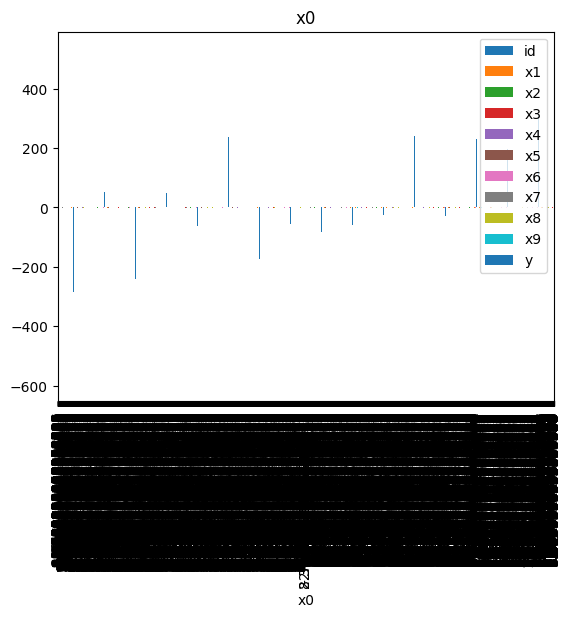

In [35]:
df.sort_values(['x0'],axis=0,ascending=[True],inplace=True)
df.head(10)
df.plot(kind='bar',x='x0')
plt.title("x0")
plt.xlabel('x0')


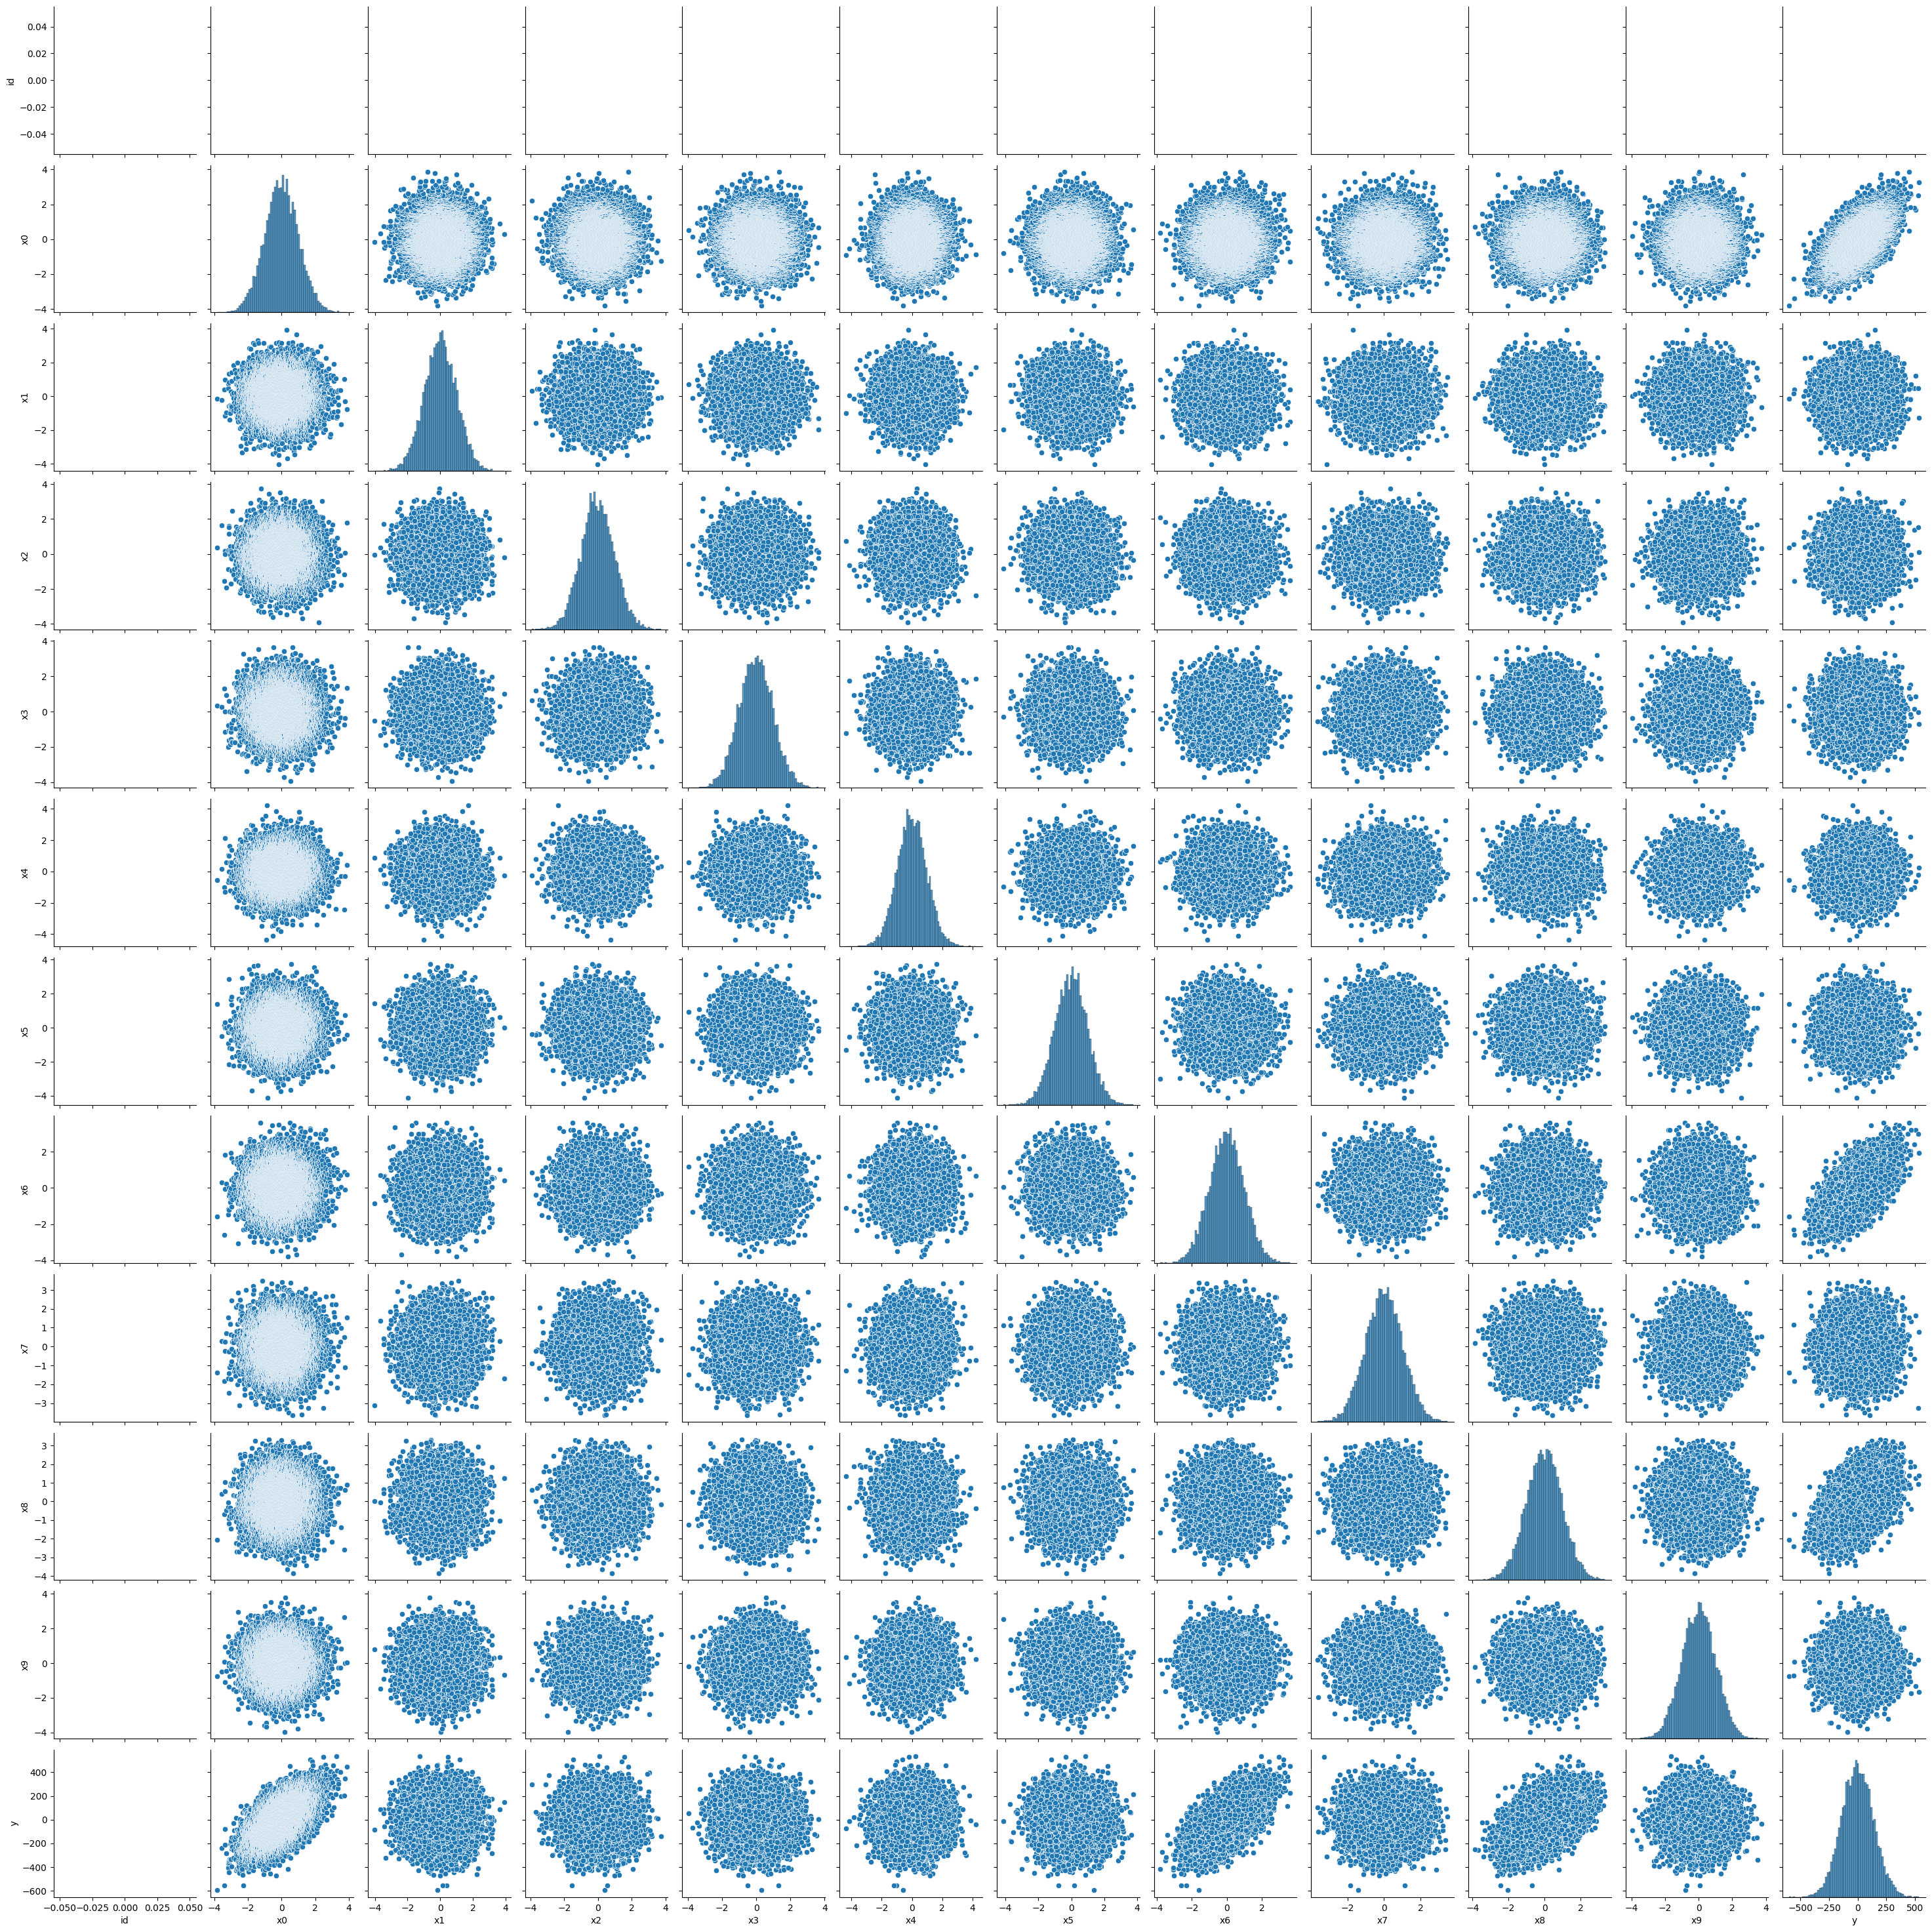

In [36]:
sns.pairplot(df)